In [2]:
!wget https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/images.npz
!wget https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/masks.npz

--2026-03-03 22:33:03--  https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/images.npz
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/refs/heads/main/images.npz [following]
--2026-03-03 22:33:04--  https://raw.githubusercontent.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/refs/heads/main/images.npz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9832112 (9.4M) [application/octet-stream]
Saving to: ‘images.npz’

images.npz          100%[===================>]   9.38M  54.9MB/s    in 0.2s    

2026-03-03 22:33:04 (54.9 MB/s) - ‘

In [3]:
print("welcome impact :)")

welcome impact :)


# for tensorflow cuda support 
- pip install "tensorflow[and-cuda]"


In [4]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [5]:
import numpy as np
import mahotas as mh
import matplotlib.pyplot as plt

In [6]:
images = np.load('images.npz')
masks = np.load('masks.npz')

In [7]:
images

NpzFile 'images.npz' with keys: images, filenames

In [8]:
masks

NpzFile 'masks.npz' with keys: masks, filenames

In [9]:
all_images = images['images']
all_masks = masks['masks']

In [10]:
all_images.shape

(208, 300, 300, 3)

In [11]:
all_masks.shape

(208, 300, 300)

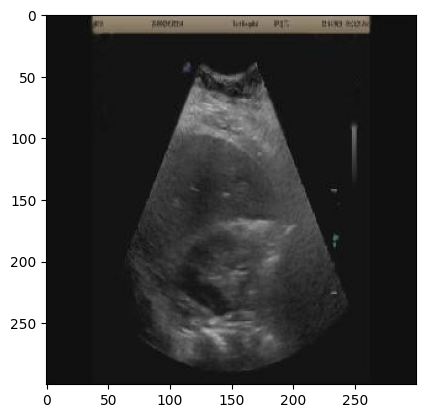

In [12]:
plt.imshow(all_images[0])

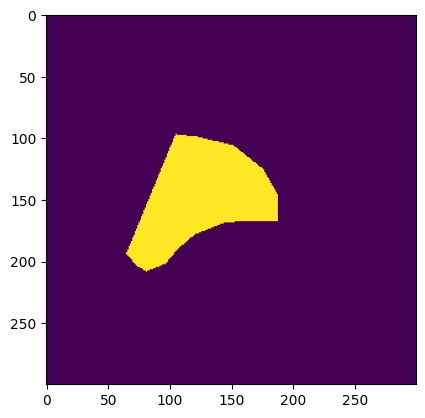

In [13]:
plt.imshow(all_masks[0])

In [14]:
all_images = all_images[:, 24:]

In [15]:
all_masks = all_masks[:, 24:]


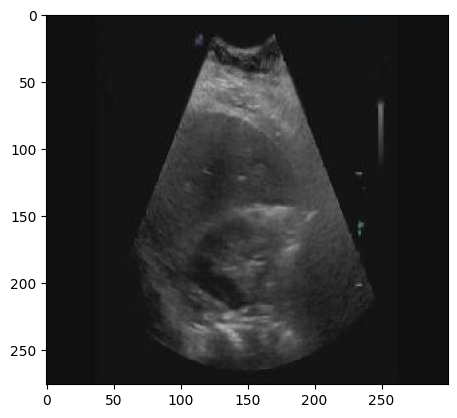

In [16]:
plt.imshow(all_images[0])

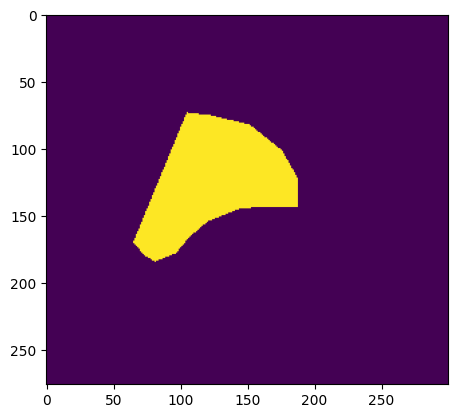

In [17]:
plt.imshow(all_masks[0])

In [18]:
all_images.shape

(208, 276, 300, 3)

In [19]:
all_masks.shape

(208, 276, 300)

In [20]:
all_masks = np.expand_dims(all_masks, axis=-1)

In [21]:
all_masks.shape

(208, 276, 300, 1)

In [22]:
x_train = all_images[0:170]
y_train = all_masks[0:170]
x_train.shape
y_train.shape


(170, 276, 300, 1)

In [23]:
x_test = all_images[170:]
y_test = all_masks[170:]
x_test.shape
y_test.shape

(38, 276, 300, 1)

In [24]:
x_train = np.pad(x_train, ((0,0),(22,22),(10,10),(0,0)))
y_train = np.pad(y_train, ((0,0),(22,22),(10,10),(0,0)))
x_test = np.pad(x_test, ((0,0),(22,22),(10,10),(0,0)))
y_test = np.pad(y_test, ((0,0),(22,22),(10,10),(0,0)))

In [25]:
x_train.shape
y_train.shape

(170, 320, 320, 1)

In [26]:
x_test.shape
y_test.shape

(38, 320, 320, 1)

In [27]:
from keras_unet.models import custom_unet

-----------------------------------------
keras-unet init: TF version is >= 2.0.0 - using `tf.keras` instead of `Keras`
-----------------------------------------


In [28]:
model = custom_unet(
    input_shape=(320, 320, 3)
)
model.compile(loss='binary_crossentropy')

I0000 00:00:1772595187.095439 1968848 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:b7:00.0, compute capability: 8.0


In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 320, 320,  │        432 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 320, 320,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 320, 320,  │      2,304 │ spatial_dropout2… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 160, 160,  │      4,608 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 160, 160,  │      9,216 │ spatial_dropout2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 80, 80,    │     18,432 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_2 │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 80, 80,    │     36,864 │ spatial_dropout2

 Total params: 1,945,521 (7.42 MB)

 Trainable params: 1,942,577 (7.41 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [30]:
!nvidia-smi

Tue Mar  3 22:33:09 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.230.02             Driver Version: 535.230.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:B7:00.0 Off |                    0 |
| N/A   37C    P0              59W / 400W |  38807MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [31]:
history = model.fit(x_train, y_train, validation_split=0.1, epochs=50)

Epoch 1/50


2026-03-03 22:33:13.609203: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f74dc0a9d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-03 22:33:13.609248: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-03-03 22:33:13.764456: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-03 22:33:14.696805: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


2/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.7815 

I0000 00:00:1772595223.377694 1969886 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 65s 8s/step - loss: 0.7178 - val_loss: 0.6102
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.6521 - val_loss: 0.5665
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.6286 - val_loss: 0.5640
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.6094 - val_loss: 0.5766
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.5866 - val_loss: 0.5682
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.5771 - val_loss: 0.5789
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.5430 - val_loss: 0.5685
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.5137 - val_loss: 0.6181
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.5107 - val_loss: 0.5476
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.4516 - val_loss: 0.6644
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.4250 - val_loss: 0.5187
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.3901 - val_loss: 0.7029
Epoch 13/50


In [33]:
y_pred = model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step


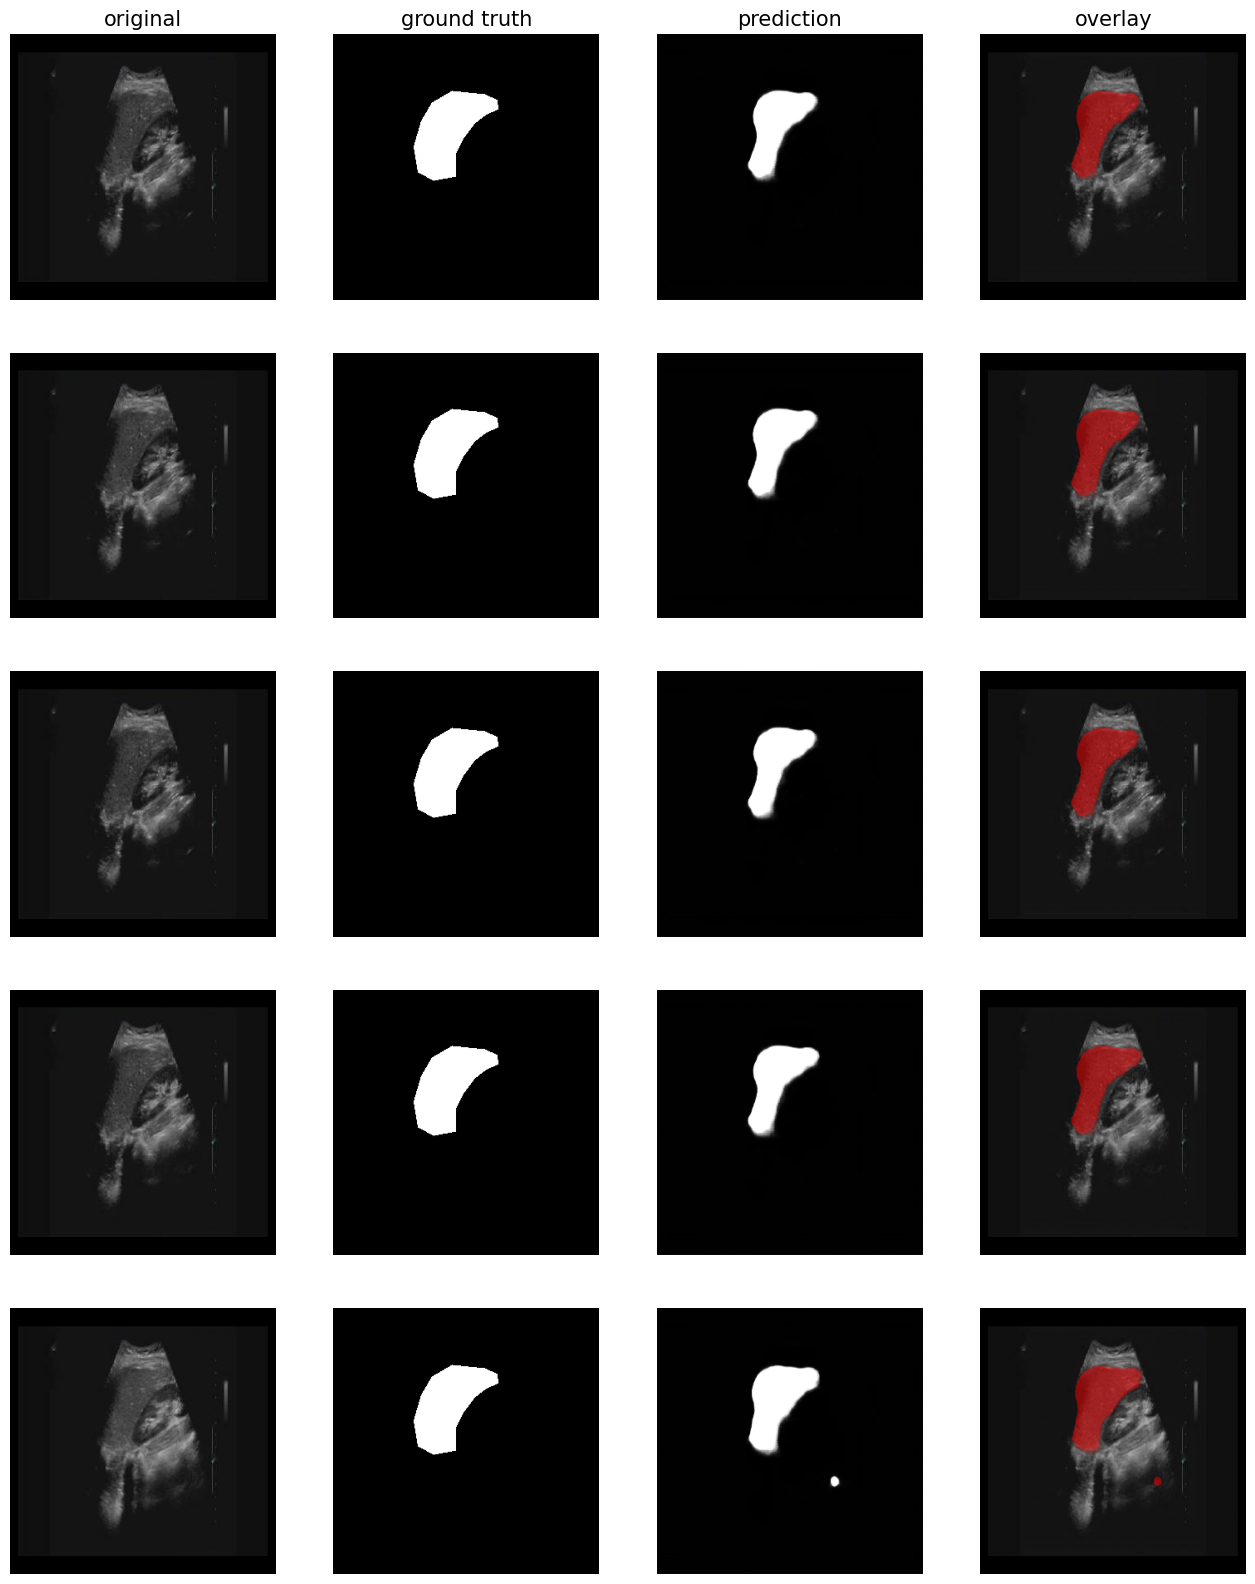

In [37]:
from keras_unet.utils import plot_imgs

plot_imgs(org_imgs=x_test, mask_imgs=y_test, pred_imgs=y_pred, nm_img_to_plot=5)